## **Import Libraries**

In [10]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## **Create Folders to Save Outputs**

In [11]:
os.makedirs("visualizations", exist_ok=True)
os.makedirs("results", exist_ok=True)

## **Set Aesthetic Plot Style**

In [12]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = 12

## **Load Dataset**

In [2]:
# Load dataset
df = pd.read_csv("Copy of house_price_regression_dataset.csv")

# Display first 5 rows
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## **Dataset Information**

In [5]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## **Data Cleaning**

In [13]:
print("Missing values:\n", df.isnull().sum())

df = df.drop_duplicates()

Missing values:
 Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


## **Visualization**

Histogram

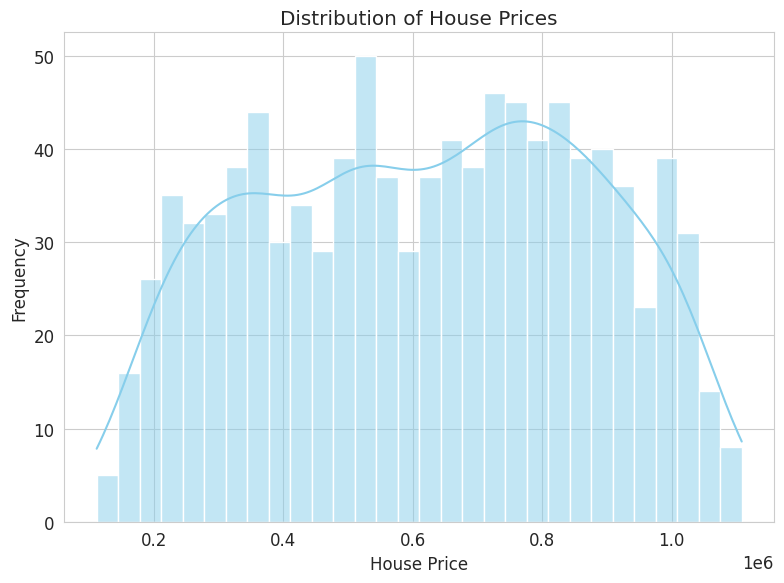

In [14]:
plt.figure()

sns.histplot(df["House_Price"], bins=30, kde=True, color="skyblue")

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("visualizations/house_price_histogram.png")
plt.show()

Boxplot

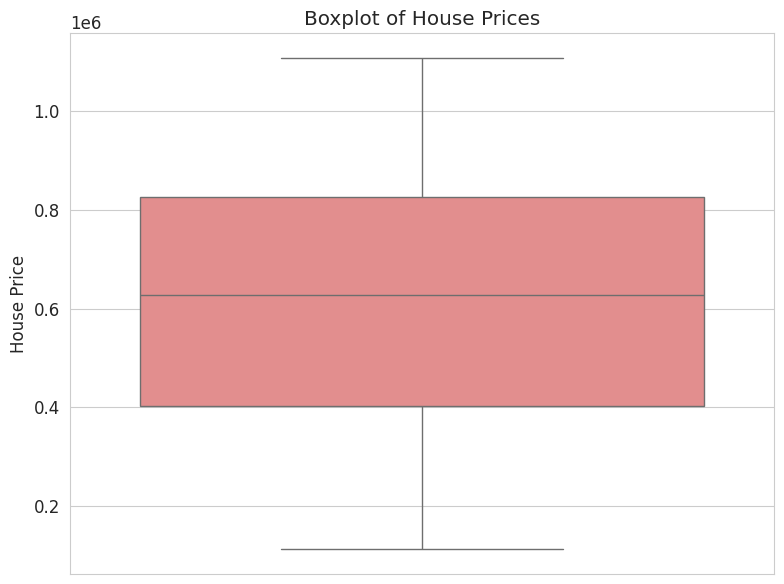

In [15]:
plt.figure()

sns.boxplot(y=df["House_Price"], color="lightcoral")

plt.title("Boxplot of House Prices")
plt.ylabel("House Price")

plt.tight_layout()
plt.savefig("visualizations/house_price_boxplot.png")
plt.show()

Correlation Heatmap

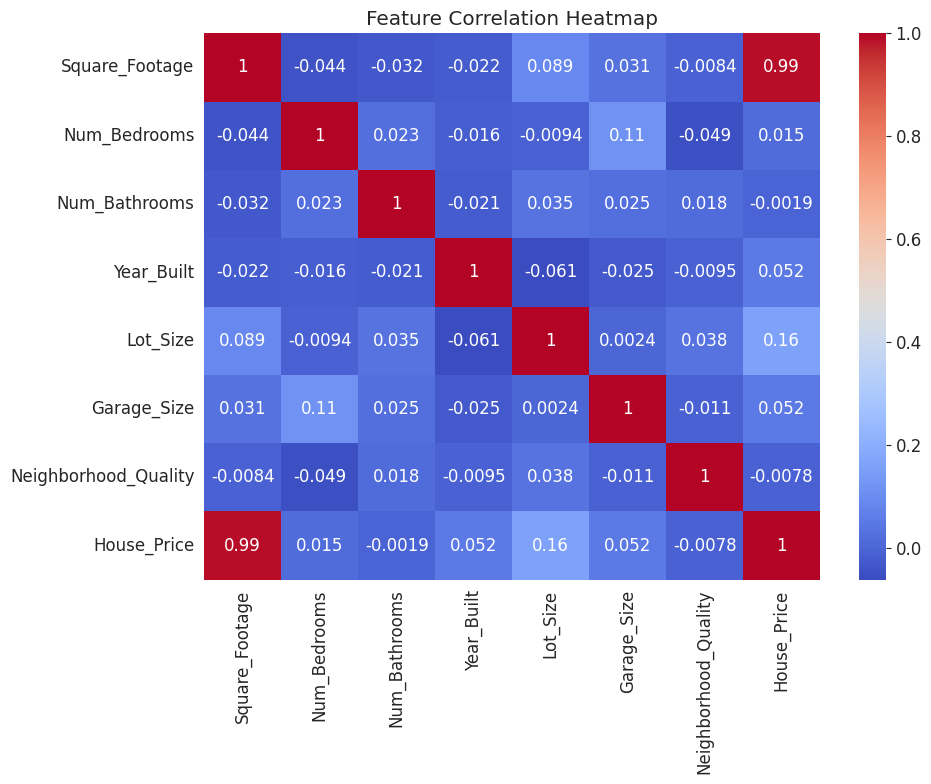

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.savefig("visualizations/correlation_heatmap.png")
plt.show()

## **Feature Selection**

In [17]:
X = df.drop("House_Price", axis=1)
y = df["House_Price"]

selector = SelectKBest(score_func=f_regression, k="all")

selector.fit(X, y)

scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

print(scores)

scores.to_csv("results/feature_scores.csv", index=False)

                Feature         Score
0        Square_Footage  56355.893907
4              Lot_Size     26.358707
5           Garage_Size      2.719833
3            Year_Built      2.702504
1          Num_Bedrooms      0.213750
6  Neighborhood_Quality      0.060256
2         Num_Bathrooms      0.003460


## **Feature Scaling**

In [18]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

## **Train Test Split**

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## **Train Linear Regression Model**

In [20]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## **Model Evaluation**

In [21]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

metrics = pd.DataFrame({
    "Metric": ["MSE", "R2 Score"],
    "Value": [mse, r2]
})

metrics.to_csv("results/model_metrics.csv", index=False)

Mean Squared Error: 101434798.5056357
R2 Score: 0.9984263636823413


## **Actual vs Predicted Plot**

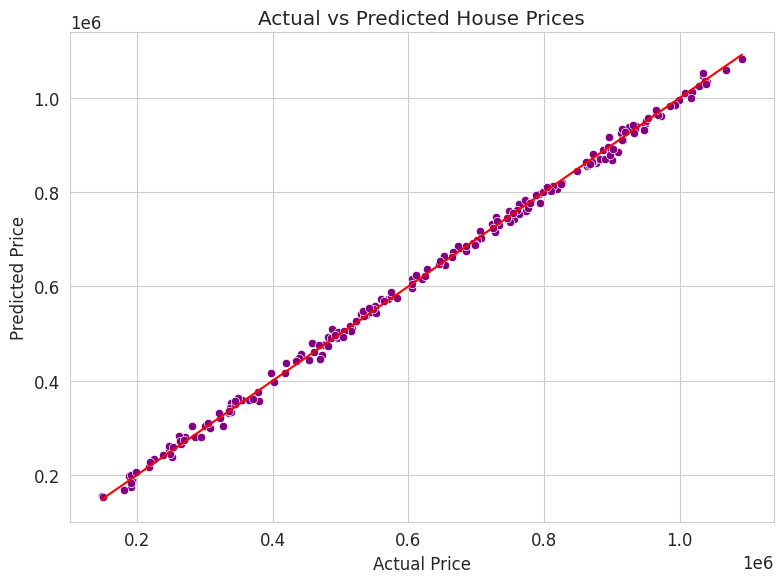

In [22]:
plt.figure()

sns.scatterplot(x=y_test, y=y_pred, color="purple")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.savefig("visualizations/actual_vs_predicted.png")

plt.show()

## **Residual Plot**

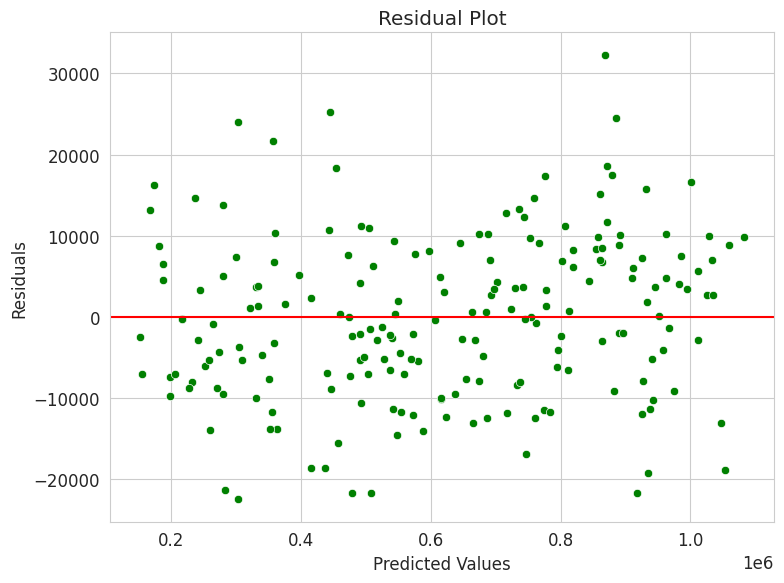

In [23]:
residuals = y_test - y_pred

plt.figure()

sns.scatterplot(x=y_pred, y=residuals, color="green")

plt.axhline(0, color="red")

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.savefig("visualizations/residual_plot.png")

plt.show()